# Fase 3: Deteksi Anomali (Penjaga Garis Depan)

## Tujuan
Membuat alarm dini menggunakan Unsupervised Learning (Isolation Forest) untuk mendeteksi perilaku sensor yang tidak wajar.

## Langkah-langkah
- 3.1: Normalisasi Data (StandardScaler / MinMaxScaler)
- 3.2: Training Isolation Forest
- 3.3: Penerapan Aturan Bisnis Rolling Window (3 jam berturut-turut)
- 3.4: Evaluasi & Visualisasi Deteksi Anomali
- 3.5: Ekspor Model (anomaly_detector.pkl)

In [1]:
# --- 3.1 Persiapan Data & Normalisasi ---
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

print("Me-load Data Ekspor (Fase 2) dan Mempersiapkan Normalisasi...\n")

# 1. Muat file hasil Fase 2
df = pd.read_csv('../data/processed/sensor_features_engineered.csv', index_col='timestamp', parse_dates=True)

# 2. Pisahkan label jawaban (ground-truth) dari fitur
if 'failure' in df.columns:
    y = df['failure']
    X = df.drop(columns=['failure', 'machine_id'], errors='ignore')
    print("Label y disimpan. Distribusi:")
    print(y.value_counts())
else:
    # Mengantisipasi jika kolom failure belum tersedia di file tsb (unsupervised murni)
    y = None
    X = df.drop(columns=['machine_id'], errors='ignore')
    print("Label 'failure' tidak ditemukan. Berjalan di mode Unsupervised murni.")

# 3. Tangani kumpulan data NaN di fitur X 
X.fillna(0, inplace=True)
print(f"\nTotal NaN di X setelah fillna: {X.isna().sum().sum()}")

# 4. Terapkan Normalisasi Standar 
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# Konversi kembali ke DataFrame agar nama kolom dan index waktu tetap terjaga
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

print(f"\nScaling selesai. Shape X_scaled: {X_scaled.shape}")

# 5. Validasi hasil normalisasi (Mean mendekati 0, Std mendekati 1)
print("\nValidasi Normalisasi (Mean & Std) dari 3 Fitur Sampel:")
for col in ['temperature', 'rpm', 'vib_spectral_energy']:
    if col in X_scaled.columns:
        print(f" - {col:25}: Mean = {X_scaled[col].mean():.4f} | Std = {X_scaled[col].std():.4f}")

print("\n✅ Langkah 3.1 Selesai. Data siap untuk Isolation Forest.")


Me-load Data Ekspor (Fase 2) dan Mempersiapkan Normalisasi...

Label y disimpan. Distribusi:
failure
0    99973
1       56
Name: count, dtype: int64

Total NaN di X setelah fillna: 0

Scaling selesai. Shape X_scaled: (100029, 34)

Validasi Normalisasi (Mean & Std) dari 3 Fitur Sampel:
 - temperature              : Mean = -0.0000 | Std = 1.0000
 - rpm                      : Mean = -0.0000 | Std = 1.0000
 - vib_spectral_energy      : Mean = 0.0000 | Std = 1.0000

✅ Langkah 3.1 Selesai. Data siap untuk Isolation Forest.


3.2 & 3.3

In [2]:
from sklearn.ensemble import IsolationForest

# 2. Konfigurasi dan latih model
model_if = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)
model_if.fit(X_scaled)
print("✅ Model Isolation Forest selesai dilatih.")

# 3. Prediksi dan konversi
raw_predictions = model_if.predict(X_scaled)
df['is_anomaly'] = (raw_predictions == -1).astype(int)

# Menampilkan hasil distribusi
print(f"\nDistribusi is_anomaly:\n{df['is_anomaly'].value_counts()}")
print(f"\nPersentase anomali terdeteksi: {df['is_anomaly'].mean()*100:.2f}%")

# 4. Pesan penutup
print("\n✅ Langkah 3.2 & 3.3 Selesai. Prediksi anomali tersimpan di kolom is_anomaly.")


✅ Model Isolation Forest selesai dilatih.

Distribusi is_anomaly:
is_anomaly
0    99028
1     1001
Name: count, dtype: int64

Persentase anomali terdeteksi: 1.00%

✅ Langkah 3.2 & 3.3 Selesai. Prediksi anomali tersimpan di kolom is_anomaly.


3.4

In [3]:
# --- 3.4 Penerapan Aturan Bisnis Rolling Window (3 jam berturut-turut) ---

# 1. Terapkan Rolling Alarm Logic PER MESIN (groupby machine_id)
df['is_rolling_anomaly'] = (
    df.groupby('machine_id')['is_anomaly']
    .rolling(window=3, min_periods=3)
    .sum()
    .reset_index(level=0, drop=True)
    .sort_index()
    >= 3
).astype(int)

# 2. Isi NaN yang timbul akibat min_periods=3 dengan 0
df['is_rolling_anomaly'].fillna(0, inplace=True)
df['is_rolling_anomaly'] = df['is_rolling_anomaly'].astype(int)

# 3. Print perbandingan sebelum vs sesudah filtering
print(f"Suspek (is_anomaly == 1)      : {df['is_anomaly'].sum()} baris")
print(f"Vonis  (is_rolling_anomaly==1): {df['is_rolling_anomaly'].sum()} baris")
print(f"False Alarm yang disaring     : {df['is_anomaly'].sum() - df['is_rolling_anomaly'].sum()} baris")

# 4. Cetak pesan penutup
print("\n✅ Langkah 3.4 Selesai. Logika Suspek vs Vonis aktif.")


Suspek (is_anomaly == 1)      : 1001 baris
Vonis  (is_rolling_anomaly==1): 692 baris
False Alarm yang disaring     : 309 baris

✅ Langkah 3.4 Selesai. Logika Suspek vs Vonis aktif.


3.5

Memvisualisasikan mesin: M-01 | Total alarm: 42


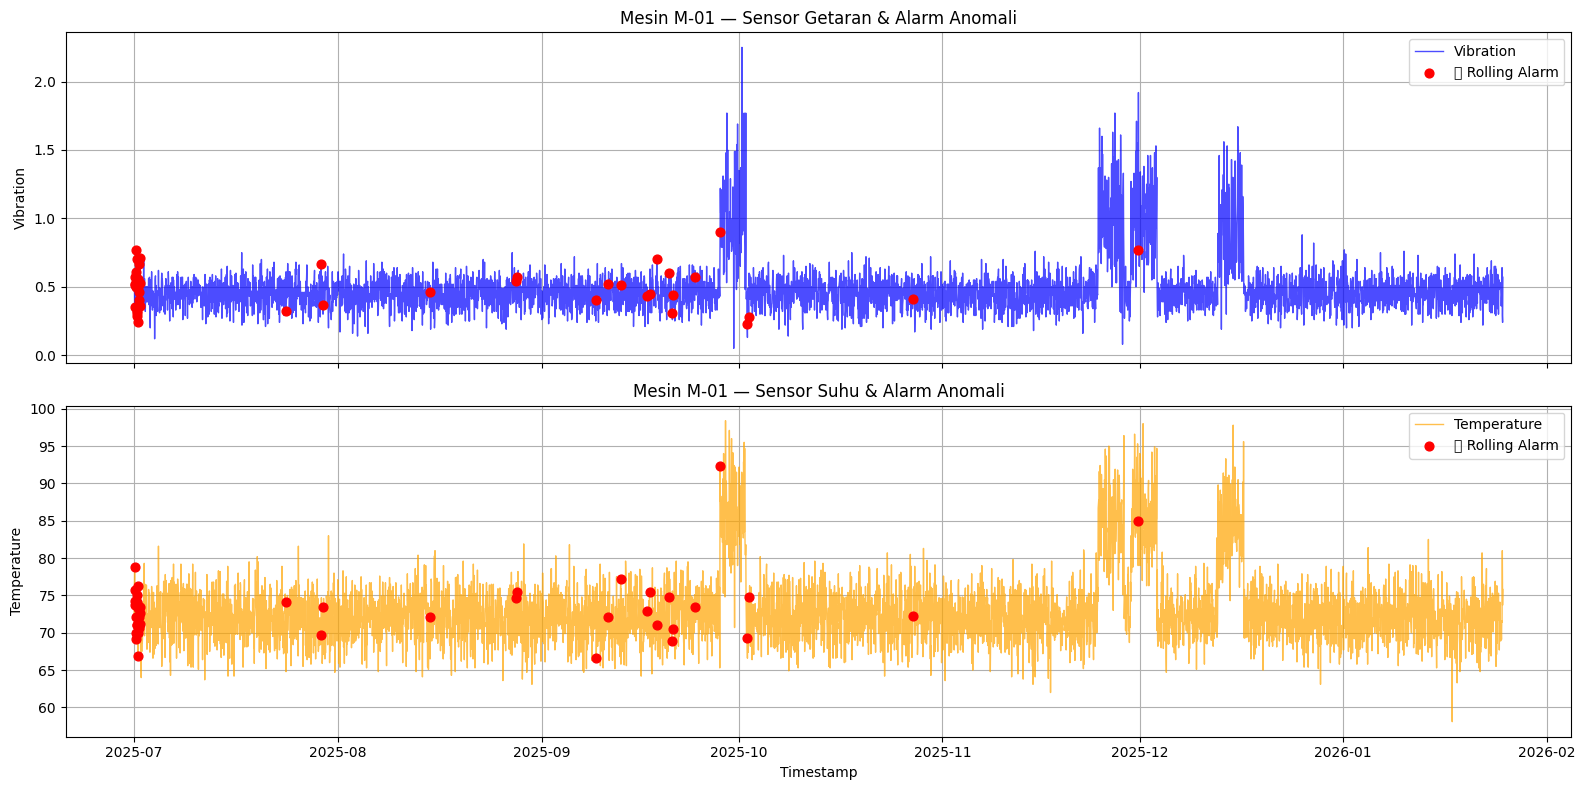


✅ Langkah 3.5 Selesai. Cek plot — titik merah harus muncul di area sensor ekstrem.


In [4]:
# --- 3.5 Evaluasi Deteksi Anomali & Visualisasi ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Pilih SATU mesin untuk divisualisasikan
# Ambil machine_id yang paling banyak menyalakan alarm anomali beruntun (rolling anomaly)
target_machine = df[df['is_rolling_anomaly'] == 1]['machine_id'].value_counts().idxmax()
df_plot = df[df['machine_id'] == target_machine].copy()

print(f"Memvisualisasikan mesin: {target_machine} | Total alarm: {df_plot['is_rolling_anomaly'].sum()}")

# 2. Buat figure dengan 2 subplot vertikal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Menentukan data yang dikenakan alarm merah
anomalies_idx = df_plot[df_plot['is_rolling_anomaly'] == 1].index
anomalies_vib = df_plot[df_plot['is_rolling_anomaly'] == 1]['vibration']
anomalies_temp = df_plot[df_plot['is_rolling_anomaly'] == 1]['temperature']

# --- SUBPLOT 1: Sensor Getaran ---
ax1.plot(df_plot.index, df_plot['vibration'], label='Vibration', color='blue', linewidth=1, alpha=0.7)
ax1.scatter(anomalies_idx, anomalies_vib, color='red', s=40, zorder=5, label='🚨 Rolling Alarm')
ax1.set_title(f'Mesin {target_machine} — Sensor Getaran & Alarm Anomali')
ax1.set_ylabel('Vibration')
ax1.legend()
ax1.grid(True)

# --- SUBPLOT 2: Sensor Suhu ---
ax2.plot(df_plot.index, df_plot['temperature'], label='Temperature', color='orange', linewidth=1, alpha=0.7)
ax2.scatter(anomalies_idx, anomalies_temp, color='red', s=40, zorder=5, label='🚨 Rolling Alarm')
ax2.set_title(f'Mesin {target_machine} — Sensor Suhu & Alarm Anomali')
ax2.set_ylabel('Temperature')
ax2.set_xlabel('Timestamp')
ax2.legend()
ax2.grid(True)

# Layout dan Save
plt.tight_layout()
plt.savefig('../data/processed/anomaly_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Pesan Penutup
print("\n✅ Langkah 3.5 Selesai. Cek plot — titik merah harus muncul di area sensor ekstrem.")


In [5]:
# --- PENYIMPANAN HASIL FASE 3: EXPORT BUNDLE MODEL V2 ---
import os
import joblib
import datetime

# 1. Perbaikan rolling logic (patch in-memory untuk memastikan df_ready up-to-date)
# Pastikan nama variabel DataFramenya valid, di sini saya pakai df karena pada langkah 3.1 Anda memakai `df`.
df['is_rolling_anomaly'] = (
    df.groupby('machine_id')['is_anomaly']
    .rolling(window=3, min_periods=3)
    .sum()
    .reset_index(level=0, drop=True)
    .sort_index()
    >= 3
).astype(int)

# Isi NaN akibat min_periods dengan 0
df['is_rolling_anomaly'].fillna(0, inplace=True)
df['is_rolling_anomaly'] = df['is_rolling_anomaly'].astype(int)

print("✅ Rolling logic diperbarui (groupby per mesin).")
print(f"   Vonis final: {df['is_rolling_anomaly'].sum()} alarm aktif.")

# 2. Buat bundle dictionary
model_bundle_v2 = {
    'model': model_if,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'metadata': {
        'version': 'v2',
        'contamination': 0.01,
        'n_estimators': 100,
        'rolling_window': 3,
        'rolling_logic': 'groupby_machine_id',
        'n_features': X.shape[1],
        'trained_on_rows': X.shape[0],
        'export_timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'phase': 'Fase 3 - Anomaly Detection',
        'project': 'Lapis AI Predictive Maintenance'
    }
}

# 3. Ekspor bundle ke disk
os.makedirs('../models/', exist_ok=True)
joblib.dump(model_bundle_v2, '../models/anomaly_detector_v2.pkl')

# 4. Verifikasi file tersimpan
file_size_kb = os.path.getsize('../models/anomaly_detector_v2.pkl') / 1024

print("\n--- Model Bundle Saved ---")
print("✅ anomaly_detector_v2.pkl berhasil diekspor.")
print(f"   Ukuran file : {file_size_kb:.1f} KB")
print(f"   Konten bundle: {list(model_bundle_v2.keys())}")
print(f"   Jumlah fitur : {model_bundle_v2['metadata']['n_features']}")
print(f"   Trained rows : {model_bundle_v2['metadata']['trained_on_rows']:,}")
print(f"   Timestamp    : {model_bundle_v2['metadata']['export_timestamp']}")
print("\n🔒 FASE 3 OFFICIALLY CLOSED. anomaly_detector_v2 siap untuk produksi.")


✅ Rolling logic diperbarui (groupby per mesin).
   Vonis final: 692 alarm aktif.

--- Model Bundle Saved ---
✅ anomaly_detector_v2.pkl berhasil diekspor.
   Ukuran file : 881.6 KB
   Konten bundle: ['model', 'scaler', 'feature_names', 'metadata']
   Jumlah fitur : 34
   Trained rows : 100,029
   Timestamp    : 2026-03-16 22:11:33

🔒 FASE 3 OFFICIALLY CLOSED. anomaly_detector_v2 siap untuk produksi.


===========================================================================================

In [ ]:
# # --- 3.1 Persiapan Data & Normalisasi ---

# # 1. Buang sisa baris yang memiliki nilai kosong (NaN) pasca-rolling/FFT
# df_ready.dropna(inplace=True)
# print(f"Dimensi data setelah dropna: {df_ready.shape}")

# # 2. Import StandardScaler
# from sklearn.preprocessing import StandardScaler

# # 3. Pisahkan label jawaban (Simpan kolom 'failure' ke variabel y)
# # Kita pastikan kita tidak terkena error jika sewaktu-waktu kolomnya berganti nama.
# if 'failure' in df_ready.columns:
#     y = df_ready['failure']
# else:
#     y = None
#     print("Himbauan: Kolom 'failure' tidak ditemukan. Mode Unsupervised murni.")

# # 4. Buat variabel fitur X dengan membuang kolom target dan kolom teks ('machine_id')
# cols_to_drop = ['machine_id']
# if 'failure' in df_ready.columns:
#     cols_to_drop.append('failure')
    
# X = df_ready.drop(columns=[col for col in cols_to_drop if col in df_ready.columns])

# # 5. Inisialisasi StandardScaler dan Lakukan Normalisasi pada X
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # 6. Mengubah array X_scaled menjadi DataFrame untuk visualisasi hasil
# X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# print("\n--- Validasi Tabel Hasil Normalisasi (StandardScaler) ---")
# display(X_scaled_df.head(5))

In [ ]:
# import numpy as np
# from sklearn.ensemble import IsolationForest

# # --- 3.2 Training Isolation Forest ---
# print("Memulai pelatihan model pendeteksi anomali Isolation Forest...")

# # 1 & 2. Inisialisasi model isolation forest
# # contamination=0.01 berarti kita berasumsi maksimal 1% data operasional adalah anomali
# model_if = IsolationForest(contamination=0.01, n_estimators=100, random_state=42)

# # 3. Latih model sekaligus memprediksi suspek anomali
# # Ini dapat memakan waktu beberapa detik karena memproses ~100.000 baris x banyak fitur
# preds = model_if.fit_predict(X_scaled)

# # 4. Menerjemahkan output model (-1 = Anomali, 1 = Normal) menjadi boolean numerik (1 = Anomali, 0 = Normal)
# df_ready['is_anomaly'] = np.where(preds == -1, 1, 0)
# print("Pelatihan selesai!\n")

# # --- 3.3 Penerapan Aturan Bisnis Rolling Window (3 jam berturut-turut) ---
# print("Memfilter status anomali dengan Aturan Bisnis (Alarm 3 Jam)...\n")

# # 5. Logika Aturan Bisnis
# # Menerapkan jendela waktu berjalan (rolling window) selama 3 jam, lalu filter 
# # apabila nilainya berjumlah 3 (berarti 3 jam berturut-turut mesin anomali)
# df_ready['is_rolling_anomaly'] = df_ready['is_anomaly'].rolling(window=3).sum() >= 3
# df_ready['is_rolling_anomaly'] = df_ready['is_rolling_anomaly'].astype(int) # Jadikan 1/0 agar rapi

# # 6. Cetak Value Counts untuk Analisis Alarm
# print("--- Distribusi Sensor Anomali (Mentah) vs Alarm (Filter) ---")
# print("1. Anomali Mentah (is_anomaly):")
# display(df_ready['is_anomaly'].value_counts())

# print("\n2. Alarm Sesungguhnya (is_rolling_anomaly):")
# display(df_ready['is_rolling_anomaly'].value_counts())

# print("\n✅ Isolasi Ekstrak Aturan Bisnis (Langkah 3.2 - 3.4) Selesai!")

In [ ]:
# import matplotlib.pyplot as plt

# # --- 3.5 Evaluasi Deteksi Anomali & Validasi Fisika ---
# print("Memulai visualisasi validasi anomali...\n")

# # 1. Cari tahu machine_id mana saja yang memicu alarm sesungguhnya
# mesin_terindikasi = df_ready[df_ready['is_rolling_anomaly'] == 1]['machine_id'].unique()
# print(f"Mesin yang memiliki alarm menyala: {mesin_terindikasi}")

# if len(mesin_terindikasi) > 0:
#     # Kita asumsikan kita mengambil satu sample mesin pertama yang rusak untuk diinvestigasi
#     target_machine = mesin_terindikasi[0]
#     print(f"\nMenggambar plot investigasi untuk mesin: {target_machine}\n")

#     # 2. Filter data hanya untuk mesin target tersebut
#     df_machine = df_ready[df_ready['machine_id'] == target_machine]

#     # Identifikasi titik-titik krusial
#     anomaly_points = df_machine[df_machine['is_rolling_anomaly'] == 1]
    
#     failure_points = pd.DataFrame() # Kosong sebagai default jika tidak ada kegagalan nyata
#     if 'failure' in df_machine.columns:
#         failure_points = df_machine[df_machine['failure'] == 1]

#     # 3. Membuat visualisasi plot 2 sumbu: Temperature dan Vibration
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
#     fig.suptitle(f'Sanity Check: Evaluasi Fisika Isolation Forest pada Mesin {target_machine}', fontsize=16)

#     # === SUBPLOT 1: TEMPERATURE ===
#     ax1.plot(df_machine.index, df_machine['temperature'], label='Suhu Normal (Celcius)', color='blue', alpha=0.6)
#     # 4. Berikan titik MERAH TEBAL saat Alarm Anomali berjalan
#     ax1.scatter(anomaly_points.index, anomaly_points['temperature'], color='red', s=100, label='Alarm Anomali Aktif', zorder=5)
#     # 5. Garis Penanda Kegagalan Nyata (Baseline Kebenaran)
#     if not failure_points.empty:
#         for failure_time in failure_points.index:
#             ax1.axvline(x=failure_time, color='black', linestyle='--', linewidth=2, label='Mesin Rusak Nyata (Failure=1)' if failure_time == failure_points.index[0] else "")
#     ax1.set_ylabel('Temperature')
#     ax1.legend()
#     ax1.grid(True)

#     # === SUBPLOT 2: VIBRATION ===
#     ax2.plot(df_machine.index, df_machine['vibration'], label='Getaran Normal (mm/s)', color='green', alpha=0.6)
#     # 4. Berikan titik MERAH TEBAL saat Alarm Anomali berjalan
#     ax2.scatter(anomaly_points.index, anomaly_points['vibration'], color='red', s=100, label='Alarm Anomali Aktif', zorder=5)
#     # 5. Garis Penanda Kegagalan Nyata (Baseline Kebenaran)
#     if not failure_points.empty:
#         for failure_time in failure_points.index:
#             ax2.axvline(x=failure_time, color='black', linestyle='--', linewidth=2, label='Mesin Rusak Nyata (Failure=1)' if failure_time == failure_points.index[0] else "")
#     ax2.set_xlabel('Timestamp')
#     ax2.set_ylabel('Vibration')
#     ax2.legend()
#     ax2.grid(True)

#     plt.tight_layout()
#     plt.show()
# else:
#     print("TIDAK ADA mesin yang terindikasi anomali (alarm tidak pernah menyala).")


In [ ]:
# import os
# import joblib

# # --- Ekspor Model --- 
# print("Mempersiapkan ekspor model Isolation Forest...")

# # 1. Tentukan path direktori penyimpanan model target
# model_dir = '../models/'

# # 2. Jika direktori 'models' belum ada, ciptakan secara otomatis (mirip mkdir -p)
# os.makedirs(model_dir, exist_ok=True)

# model_path = os.path.join(model_dir, 'anomaly_detector.pkl')

# # 3. Lakukan proses Pickling (Dump) arsitektur model beserta otak (weights)-nya ke format biner (.pkl)
# joblib.dump(model_if, model_path)

# # 4. Konfirmasi Kesuksesan
# print(f"✅ Model Isolation Forest berhasil diekspor ke {model_path}!")
# print("Model ini sekarang sudah beku (frozen) dan siap dipanggil (loaded) kapanpun di sistem produksi.")